In [1]:
import xarray
import pandas as pd
import numpy as np

import datetime

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import glob
from scipy.interpolate import RegularGridInterpolator

kk = 630
ee = 820



# Open HSRL file here.

In [2]:
dat = '20190915'
base_date = pd.Timestamp('2019-09-15')
ds_nav = xarray.open_dataset(f'/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', 
                             phony_dims='access', group='Nav_Data')
base_jday = ds_nav['Jday'][:,0].values[0]
day_deltas = ds_nav['Jday'][:,0].values - base_jday
time_deltas = pd.to_timedelta(ds_nav['gps_time'][:,0].values, unit='h')
dates = base_date + pd.to_timedelta(day_deltas, unit='D')
date_times = dates + time_deltas
formatted_dates = date_times.strftime('%Y-%m-%d %H:%M:%S')

ds_nav['Date'] = xarray.DataArray(
    formatted_dates,
    dims=["time"]
)

df_nav = ds_nav['Date'].to_dataframe().reset_index()
df_nav['time'] = pd.to_datetime(df_nav['time'])

dat = '20190915'
dat1 = '2019-09-15-03600'
dat2 = '2019-09-16-03600'
workdir = '/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/'
p3file = f'CAMP2Ex-mrg01-P3B-NC_merge_{dat}_R3.nc'
p3data_ds = xarray.open_dataset(workdir+p3file)

variables = ['AOT532_hi', 'MLH']
selected_data = p3data_ds[variables]
p3data = selected_data.to_dataframe().reset_index()
p3data['time'] = pd.to_datetime(p3data['time'].dt.strftime("%Y-%m-%d %H:%M:%S"))

df_nav_ = pd.merge(df_nav, p3data, on='time', how='inner')

ds_one = xarray.open_dataset(f'/home/svisaga/MUSICA_ANALYSES/WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', phony_dims='access', group='DataProducts')
variable_data = ds_one['532_ext']

# Open MUSICAv0 file here

In [3]:
def extract_level(df, lev):
    """
    Extract a single model level time series.
    lev: model level number (1–30)
    """
    return (
        df.loc[df['nl'] == (31 - lev), ['datetime', 'alt_mod']]
          .set_index('datetime')
          .to_xarray()
    )


In [4]:
# ---------------------------------------------------------
# LOAD HSRL (OBS) FOR CONTROL COMPARISON
# ---------------------------------------------------------

file_pattern = '/home/svisaga/MUSICA_ANALYSES/curtain_tracks/hsrl_20190915_curtain_CAMP2Ex.nc'
file_list = glob.glob(file_pattern)

ds = xarray.open_mfdataset(file_list, combine='by_coords')
ds = ds.isel(Date=slice(kk, ee))

average_per_altitude = ds.mean(dim='Date')
std_per_altitude     = ds.std(dim='Date')

constant_altitudes_ctrl = ds.Altitude.values


# ---------------------------------------------------------
# LOAD CONTROL MODEL DATA
# ---------------------------------------------------------

file_list_ctrl = [
    "/home/svisaga/MUSICA_ANALYSES/curtain_tracks/p3_2019-09-15-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "/home/svisaga/MUSICA_ANALYSES/curtain_tracks/p3_2019-09-16-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod_ctrl = xarray.open_mfdataset(file_list_ctrl, combine='by_coords')

common_dates_ctrl = np.intersect1d(ds['Date'], ds_mod_ctrl['datetime'].values)
ds_mod_ctrl = ds_mod_ctrl.sel(datetime=common_dates_ctrl)
ds_mod_ctrl['datetime'] = pd.to_datetime(ds_mod_ctrl['datetime'].values)

# IMPORTANT: include all variables needed later
variables_ctrl = ['alt_mod', 'EXTINCT_mod', 'pblh_mod', 'u_mod', 'v_mod', 'w_mod']
ds_mod_ctrl = ds_mod_ctrl[variables_ctrl]

df_mod_ctrl = ds_mod_ctrl.to_dataframe().reset_index()
df_mod_ctrl['datetime'] = pd.to_datetime(df_mod_ctrl['datetime'])


# ---------------------------------------------------------
# INTERPOLATE CONTROL MODEL TO CONSTANT ALTITUDE GRID
# ---------------------------------------------------------

df_mod_interp_ctrl = []
grouped_ctrl = df_mod_ctrl.groupby('datetime')

for name, group in grouped_ctrl:
    group_sorted = group.sort_values('alt_mod')

    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    valid_altitudes = constant_altitudes_ctrl[
        (constant_altitudes_ctrl >= min_alt) &
        (constant_altitudes_ctrl <= max_alt)
    ]

    extinct_interp = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])
    u_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['u_mod'])
    v_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['v_mod'])
    w_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['w_mod'])

    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': extinct_interp,
        'u_mod': u_interp,
        'v_mod': v_interp,
        'w_mod': w_interp
    })

    df_mod_interp_ctrl.append(interpolated_df)

df_mod_interp_ctrl = pd.concat(df_mod_interp_ctrl, ignore_index=True)

grouped_mean_ctrl = df_mod_interp_ctrl.groupby('altitude').mean().reset_index()
grouped_std_ctrl  = df_mod_interp_ctrl.groupby('altitude').std().reset_index()

#############################################################################
# Pivot into matrices — CONTROL
#############################################################################

u_vals_ctrl = df_mod_interp_ctrl.pivot(
    index='datetime', columns='altitude', values='u_mod'
).values

v_vals_ctrl = df_mod_interp_ctrl.pivot(
    index='datetime', columns='altitude', values='v_mod'
).values

w_vals_ctrl = df_mod_interp_ctrl.pivot(
    index='datetime', columns='altitude', values='w_mod'
).values

# Matching coordinate arrays
time_vals_mod_ctrl = df_mod_interp_ctrl['datetime'].unique()
alt_vals_mod_ctrl  = df_mod_interp_ctrl['altitude'].unique()

# Pivot into time × altitude DataFrames (needed for quiver)
df_u_ctrl = df_mod_interp_ctrl.pivot_table(
    index='datetime',
    columns='altitude',
    values='u_mod',
    aggfunc='mean'
).sort_index(axis=1)

df_v_ctrl = df_mod_interp_ctrl.pivot_table(
    index='datetime',
    columns='altitude',
    values='v_mod',
    aggfunc='mean'
).sort_index(axis=1)

df_w_ctrl = df_mod_interp_ctrl.pivot_table(
    index='datetime',
    columns='altitude',
    values='w_mod',
    aggfunc='mean'
).sort_index(axis=1)

df_mod_pblh_ctrl = df_mod_ctrl[['datetime','pblh_mod']].drop_duplicates()
ds_mod_pblh_interp_ctrl = df_mod_pblh_ctrl.set_index(['datetime']).to_xarray()

ds_mod_interp_ctrl = df_mod_interp_ctrl.set_index(['datetime', 'altitude']).to_xarray()
curt_time_ctrl = ds_mod_interp_ctrl['datetime']
curt_time_np_ctrl = np.array(curt_time_ctrl, dtype='datetime64')
curt_time2_ctrl = np.tile(
    curt_time_np_ctrl[:, np.newaxis],
    (1, ds_mod_interp_ctrl['EXTINCT_mod'].shape[1])
)

# Full model (no 6 km cut)
ds_mod_all_ctrl = df_mod_ctrl.set_index(['datetime', 'alt_mod']).to_xarray()

# Time slicing
startdate_ctrl = '2019-09-15 23:41:00'
enddate_ctrl   = '2019-09-16 00:13:00'
filedate_ctrl  = '0915_2341'

ds_mod_interp__ctrl = ds_mod_interp_ctrl.sel(datetime=slice(startdate_ctrl, enddate_ctrl))
ds_mod_all__ctrl    = ds_mod_all_ctrl.sel(datetime=slice(startdate_ctrl, enddate_ctrl))

# Extract levels
levels_to_plot_ctrl = range(15, 31)

ds_levels_ctrl = {
    lev: extract_level(df_mod_ctrl, lev).sel(datetime=slice(startdate_ctrl, enddate_ctrl))
    for lev in levels_to_plot_ctrl
}

ds_mod_pblh_interp__ctrl = ds_mod_pblh_interp_ctrl.sel(datetime=slice(startdate_ctrl, enddate_ctrl))

# ---------------------------------------------------------
# WIND VECTORS FOR PANEL (c) — CONTROL
# ---------------------------------------------------------

model_times_ctrl = df_u_ctrl.index.values
altitudes_m_ctrl = df_u_ctrl.columns.values / 1000.0

# Convert to arrays
u_matrix_ctrl = df_u_ctrl.values
v_matrix_ctrl = df_v_ctrl.values
w_matrix_ctrl = df_w_ctrl.values

# Decimate
t_step_ctrl = 5
z_step_ctrl = 6

u_mod_dec_ctrl = u_matrix_ctrl[::t_step_ctrl, ::z_step_ctrl]
v_mod_dec_ctrl = v_matrix_ctrl[::t_step_ctrl, ::z_step_ctrl]
w_mod_dec_ctrl = w_matrix_ctrl[::t_step_ctrl, ::z_step_ctrl]

time_mod_dec_ctrl = model_times_ctrl[::t_step_ctrl]
alt_mod_dec_ctrl  = altitudes_m_ctrl[::z_step_ctrl]

# Meshgrid
Tmod_ctrl, Zmod_ctrl = np.meshgrid(time_mod_dec_ctrl, alt_mod_dec_ctrl, indexing='ij')


/tmp/ipykernel_3019987/3016501013.py:76: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_ctrl = df_mod_interp_ctrl.groupby('altitude').mean().reset_index()
/tmp/ipykernel_3019987/3016501013.py:77: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_ctrl  = df_mod_interp_ctrl.groupby('altitude').std().reset_index()


In [5]:
# ---------------------------------------------------------
# LOAD & ALIGN EXP01 DATA
# ---------------------------------------------------------

file_list_exp01 = [
    "/home/svisaga/MUSICA_Paper1_figures_for_Exp01/curtain_tracks/p3_2019-09-15-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "/home/svisaga/MUSICA_Paper1_figures_for_Exp01/curtain_tracks/p3_2019-09-16-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod_exp01 = xarray.open_mfdataset(file_list_exp01, combine='by_coords')

common_dates_exp01 = np.intersect1d(ds['Date'], ds_mod_exp01['datetime'].values)
ds_mod_exp01 = ds_mod_exp01.sel(datetime=common_dates_exp01)
ds_mod_exp01['datetime'] = pd.to_datetime(ds_mod_exp01['datetime'].values)

variables_exp01 = ['alt_mod', 'EXTINCT_mod', 'pblh_mod', 'u_mod', 'v_mod', 'w_mod']
ds_mod_exp01 = ds_mod_exp01[variables_exp01]

df_mod_exp01 = ds_mod_exp01.to_dataframe().reset_index()
df_mod_exp01['datetime'] = pd.to_datetime(df_mod_exp01['datetime'])

constant_altitudes_exp01 = ds.Altitude.values

# ---------------------------------------------------------
# INTERPOLATION TO CONSTANT ALTITUDE GRID
# ---------------------------------------------------------

df_mod_interp_exp01 = []
grouped_exp01 = df_mod_exp01.groupby('datetime')

for name, group in grouped_exp01:
    group_sorted = group.sort_values('alt_mod')

    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    valid_altitudes = constant_altitudes_exp01[
        (constant_altitudes_exp01 >= min_alt) &
        (constant_altitudes_exp01 <= max_alt)
    ]

    extinct_interp = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])
    u_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['u_mod'])
    v_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['v_mod'])
    w_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['w_mod'])

    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': extinct_interp,
        'u_mod': u_interp,
        'v_mod': v_interp,
        'w_mod': w_interp
    })

    df_mod_interp_exp01.append(interpolated_df)

df_mod_interp_exp01 = pd.concat(df_mod_interp_exp01, ignore_index=True)

grouped_mean_exp01 = df_mod_interp_exp01.groupby('altitude').mean().reset_index()
grouped_std_exp01  = df_mod_interp_exp01.groupby('altitude').std().reset_index()

# ---------------------------------------------------------
# PIVOT INTO MATRICES
# ---------------------------------------------------------

u_vals_exp01 = df_mod_interp_exp01.pivot(index='datetime', columns='altitude', values='u_mod').values
v_vals_exp01 = df_mod_interp_exp01.pivot(index='datetime', columns='altitude', values='v_mod').values
w_vals_exp01 = df_mod_interp_exp01.pivot(index='datetime', columns='altitude', values='w_mod').values

time_vals_mod_exp01 = df_mod_interp_exp01['datetime'].unique()
alt_vals_mod_exp01  = df_mod_interp_exp01['altitude'].unique()

df_u_exp01 = df_mod_interp_exp01.pivot_table(
    index='datetime', columns='altitude', values='u_mod', aggfunc='mean'
).sort_index(axis=1)

df_v_exp01 = df_mod_interp_exp01.pivot_table(
    index='datetime', columns='altitude', values='v_mod', aggfunc='mean'
).sort_index(axis=1)

df_w_exp01 = df_mod_interp_exp01.pivot_table(
    index='datetime', columns='altitude', values='w_mod', aggfunc='mean'
).sort_index(axis=1)

df_mod_pblh_exp01 = df_mod_exp01[['datetime', 'pblh_mod']].drop_duplicates()
ds_mod_pblh_interp_exp01 = df_mod_pblh_exp01.set_index(['datetime']).to_xarray()

ds_mod_interp_exp01 = df_mod_interp_exp01.set_index(['datetime', 'altitude']).to_xarray()

curt_time_exp01 = ds_mod_interp_exp01['datetime']
curt_time_np_exp01 = np.array(curt_time_exp01, dtype='datetime64')
curt_time2_exp01 = np.tile(
    curt_time_np_exp01[:, np.newaxis],
    (1, ds_mod_interp_exp01['EXTINCT_mod'].shape[1])
)

# ---------------------------------------------------------
# FULL MODEL (NO 6 KM CUT)
# ---------------------------------------------------------

ds_mod_all_exp01 = df_mod_exp01.set_index(['datetime', 'alt_mod']).to_xarray()

# ---------------------------------------------------------
# TIME SLICE
# ---------------------------------------------------------

startdate_exp01 = '2019-09-15 23:41:00'
enddate_exp01   = '2019-09-16 00:13:00'
filedate_exp01  = '0915_2341'

ds_mod_interp__exp01 = ds_mod_interp_exp01.sel(datetime=slice(startdate_exp01, enddate_exp01))
ds_mod_all__exp01    = ds_mod_all_exp01.sel(datetime=slice(startdate_exp01, enddate_exp01))

# ---------------------------------------------------------
# EXTRACT LEVELS
# ---------------------------------------------------------

levels_to_plot_exp01 = range(15, 31)

ds_levels_exp01 = {
    lev: extract_level(df_mod_exp01, lev).sel(datetime=slice(startdate_exp01, enddate_exp01))
    for lev in levels_to_plot_exp01
}

ds_mod_pblh_interp__exp01 = ds_mod_pblh_interp_exp01.sel(datetime=slice(startdate_exp01, enddate_exp01))

# ---------------------------------------------------------
# WIND VECTORS FOR PANEL (c)
# ---------------------------------------------------------

model_times_exp01 = df_u_exp01.index.values
altitudes_m_exp01 = df_u_exp01.columns.values / 1000.0

u_matrix_exp01 = df_u_exp01.values
v_matrix_exp01 = df_v_exp01.values
w_matrix_exp01 = df_w_exp01.values

t_step_exp01 = 5
z_step_exp01 = 6

u_mod_dec_exp01 = u_matrix_exp01[::t_step_exp01, ::z_step_exp01]
v_mod_dec_exp01 = v_matrix_exp01[::t_step_exp01, ::z_step_exp01]
w_mod_dec_exp01 = w_matrix_exp01[::t_step_exp01, ::z_step_exp01]

time_mod_dec_exp01 = model_times_exp01[::t_step_exp01]
alt_mod_dec_exp01  = altitudes_m_exp01[::z_step_exp01]

Tmod_exp01, Zmod_exp01 = np.meshgrid(time_mod_dec_exp01, alt_mod_dec_exp01, indexing='ij')


/tmp/ipykernel_3019987/3220253400.py:60: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_exp01 = df_mod_interp_exp01.groupby('altitude').mean().reset_index()
/tmp/ipykernel_3019987/3220253400.py:61: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_exp01  = df_mod_interp_exp01.groupby('altitude').std().reset_index()


In [6]:
ds_mod_pblh_interp__exp01

<xarray.Dataset>
Dimensions:   (datetime: 190)
Coordinates:
  * datetime  (datetime) datetime64[ns] 2019-09-15T23:41:07 ... 2019-09-16T00...
Data variables:
    pblh_mod  (datetime) float64 725.8 725.7 725.3 725.3 ... 555.6 555.7 555.9

/tmp/ipykernel_3019987/1901096610.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


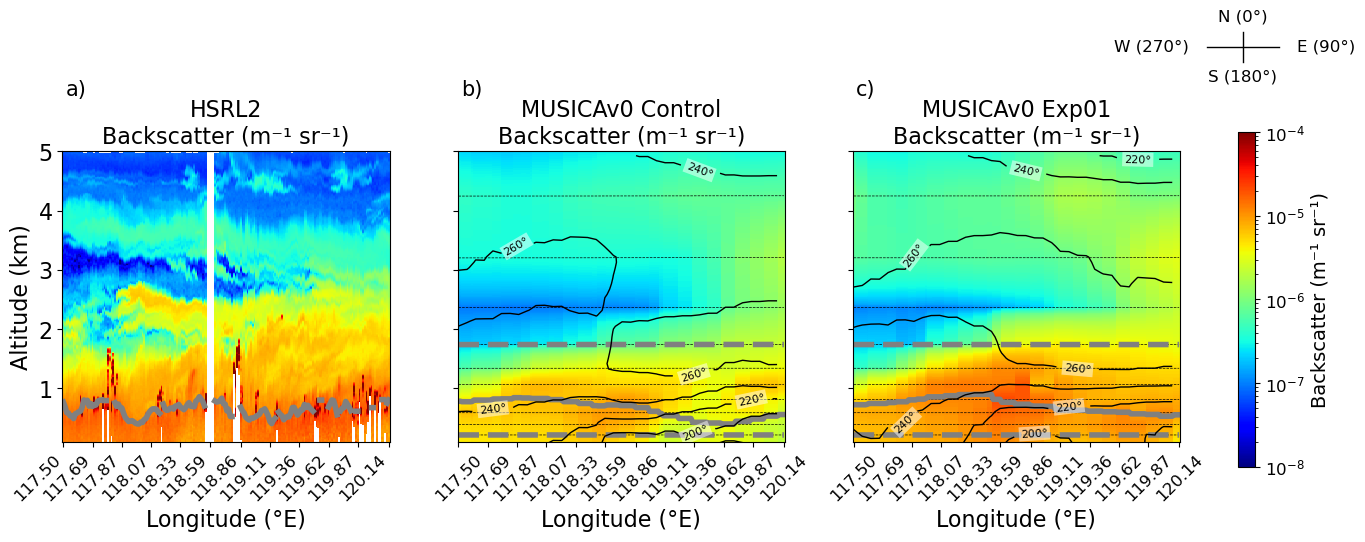

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter

# ---------------------------------------------------------
# Precompute tick positions and labels for HSRL (lon axis)
# ---------------------------------------------------------
date_index = pd.DatetimeIndex(ds_nav['Date'][kk:ee].values)
lon_vals   = df_nav_['lon'].values[kk:ee]
mlh_vals   = df_nav_['MLH'].values[kk:ee]
time_vals  = df_nav_['time'].values[kk:ee]

tick_indices  = np.linspace(0, len(date_index) - 1, num=12, dtype=int)
tick_positions = date_index[tick_indices]
tick_labels    = [f"{lon_vals[i]:.2f}" for i in tick_indices]

# ---------------------------------------------------------
# Create 1 row × 3 column figure
# ---------------------------------------------------------
fig, (ax0, ax1, ax2) = plt.subplots(
    1, 3, figsize=(12, 5), sharey=True,
    gridspec_kw={"width_ratios": [1, 1, 1]}
)
fig.subplots_adjust(wspace=0.15)

# =========================================================
# PANEL (a) — HSRL2
# =========================================================
ax0.text(0.01, 1.18, "a)", transform=ax0.transAxes,
         fontsize=15, va="bottom", ha="left")

c0 = ax0.pcolormesh(
    date_index,
    ds_one['Altitude'][0, :].values / 1000,
    ds_one['532_bsc'][kk:ee, :].T / 1000,
    norm=mcolors.LogNorm(vmin=1E-8, vmax=1E-4),
    cmap="jet"
)

ax0.plot(time_vals, mlh_vals/1000, color='gray', linewidth=4)

ax0.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in ax0.xaxis.get_majorticklabels():
    label.set_horizontalalignment('right')

ax0.set_xticks(tick_positions)
ax0.set_xticklabels(tick_labels, rotation=45, fontsize=12)
ax0.set_xlabel("Longitude (°E)", fontsize=16)
ax0.set_title("HSRL2\nBackscatter (m⁻¹ sr⁻¹)", fontsize=16)
ax0.set_ylim(0.1, 5)
ax0.tick_params(axis='y', labelsize=16)
ax0.set_ylabel("Altitude (km)", fontsize=16)


# =========================================================
# COMMON WIND-DIRECTION CONTOUR LEVELS (45° ONLY)
# =========================================================
levels_45 = np.arange(0, 361, 20)
z_thresh = 5  # km


# =========================================================
# PANEL (b) — MUSICAv0 Control
# =========================================================
ax1.text(0.01, 1.18, "b)", transform=ax1.transAxes,
         fontsize=15, va="bottom", ha="left")

c1 = ax1.pcolormesh(
    ds_mod_interp__ctrl['datetime'],
    ds_mod_interp__ctrl['altitude'] / 1000,
    (ds_mod_interp__ctrl['EXTINCT_mod'] / 65.74).T,
    norm=mcolors.LogNorm(vmin=1E-8, vmax=1E-4),
    cmap="jet"
)

# Model levels + PBLH
for lev, ds_lev in ds_levels_ctrl.items():
    ax1.plot(ds_lev['datetime'], ds_lev['alt_mod']/1000,
             linewidth=0.5, linestyle='--', color='k')

ax1.plot(ds_mod_pblh_interp__ctrl['datetime'],
         ds_mod_pblh_interp__ctrl['pblh_mod']/1000,
         color='gray', linewidth=4)
ax1.plot(ds_levels_ctrl[24]['datetime'], ds_levels_ctrl[24]['alt_mod']/1000,
         color='gray', linewidth=4, linestyle='--')
ax1.plot(ds_levels_ctrl[30]['datetime'], ds_levels_ctrl[30]['alt_mod']/1000,
         color='gray', linewidth=4, linestyle='--')

# ---------------------------------------------------------
# WIND DIRECTION — CONTROL
# ---------------------------------------------------------
theta_math_ctrl = np.degrees(np.arctan2(v_mod_dec_ctrl, u_mod_dec_ctrl))
wind_dir_ctrl_raw = (270 - theta_math_ctrl) % 360
wind_dir_ctrl = gaussian_filter(wind_dir_ctrl_raw, sigma=0.3)

wind_dir_ctrl_low = np.where(Zmod_ctrl <= z_thresh, wind_dir_ctrl, np.nan)

# 45° contours
cont_ctrl = ax1.contour(
    Tmod_ctrl, Zmod_ctrl, wind_dir_ctrl_low,
    levels=levels_45, colors='k', linewidths=1.0
)

# Labels on every 45° contour
labels_ctrl = ax1.clabel(
    cont_ctrl, fmt='%d°', fontsize=8, colors='k'
)

for t in labels_ctrl:
    t.set_bbox(dict(facecolor=(1, 1, 1, 0.5), edgecolor='none', pad=1.5))

ax1.set_title("MUSICAv0 Control\nBackscatter (m⁻¹ sr⁻¹)", fontsize=16)
ax1.set_ylim(0.1, 5)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=45, fontsize=12)
ax1.set_xlabel("Longitude (°E)", fontsize=16)


# =========================================================
# PANEL (c) — MUSICAv0 Exp01
# =========================================================
ax2.text(0.01, 1.18, "c)", transform=ax2.transAxes,
         fontsize=15, va="bottom", ha="left")

c2 = ax2.pcolormesh(
    ds_mod_interp__exp01['datetime'],
    ds_mod_interp__exp01['altitude'] / 1000,
    (ds_mod_interp__exp01['EXTINCT_mod'] / 65.74).T,
    norm=mcolors.LogNorm(vmin=1E-8, vmax=1E-4),
    cmap="jet"
)

for lev, ds_lev in ds_levels_exp01.items():
    ax2.plot(ds_lev['datetime'], ds_lev['alt_mod']/1000,
             linewidth=0.5, linestyle='--', color='k')

ax2.plot(ds_mod_pblh_interp__exp01['datetime'],
         ds_mod_pblh_interp__exp01['pblh_mod']/1000,
         color='gray', linewidth=4)
ax2.plot(ds_levels_exp01[24]['datetime'], ds_levels_exp01[24]['alt_mod']/1000,
         color='gray', linewidth=4, linestyle='--')
ax2.plot(ds_levels_exp01[30]['datetime'], ds_levels_exp01[30]['alt_mod']/1000,
         color='gray', linewidth=4, linestyle='--')

# ---------------------------------------------------------
# WIND DIRECTION — EXP01
# ---------------------------------------------------------
theta_math_exp01 = np.degrees(np.arctan2(v_mod_dec_exp01, u_mod_dec_exp01))
wind_dir_exp01_raw = (270 - theta_math_exp01) % 360
wind_dir_exp01 = gaussian_filter(wind_dir_exp01_raw, sigma=0.3)

wind_dir_exp01_low = np.where(Zmod_exp01 <= z_thresh, wind_dir_exp01, np.nan)

# 45° contours
cont_exp01 = ax2.contour(
    Tmod_exp01, Zmod_exp01, wind_dir_exp01_low,
    levels=levels_45, colors='k', linewidths=1.0
)

# Labels
labels_exp01 = ax2.clabel(
    cont_exp01, fmt='%d°', fontsize=8, colors='k'
)

for t in labels_exp01:
    t.set_bbox(dict(facecolor=(1, 1, 1, 0.5), edgecolor='none', pad=1.5))

ax2.set_title("MUSICAv0 Exp01\nBackscatter (m⁻¹ sr⁻¹)", fontsize=16)
ax2.set_ylim(0.1, 5)
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels, rotation=45, fontsize=12)
ax2.set_xlabel("Longitude (°E)", fontsize=16)


# =========================================================
# SINGLE COLORBAR
# =========================================================
cbar = fig.colorbar(c2, ax=[ax0, ax1, ax2], fraction=0.018, pad=0.04)

pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 + 0.15, pos.y0, pos.width, pos.height])

cbar.set_label("Backscatter (m⁻¹ sr⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ---------------------------------------------------------
# Minimalist wind-direction compass
# ---------------------------------------------------------
compass_x = 1.04
compass_y = 1.

fig.lines.append(plt.Line2D(
    [compass_x, compass_x], [compass_y - 0.03, compass_y + 0.03],
    transform=fig.transFigure, color='black', linewidth=1
))
fig.lines.append(plt.Line2D(
    [compass_x - 0.03, compass_x + 0.03], [compass_y, compass_y],
    transform=fig.transFigure, color='black', linewidth=1
))

fig.text(compass_x, compass_y + 0.045, "N (0°)",
         ha='center', va='bottom', fontsize=12)
fig.text(compass_x + 0.045, compass_y, "E (90°)",
         ha='left', va='center', fontsize=12)
fig.text(compass_x, compass_y - 0.045, "S (180°)",
         ha='center', va='top', fontsize=12)
fig.text(compass_x - 0.045, compass_y, "W (270°)",
         ha='right', va='center', fontsize=12)

plt.tight_layout()
plt.savefig("output/img/Figure8_AMSPaper.png",
            dpi=300, bbox_inches="tight")
